# BINF 4211: Applied Data Mining for Bioinformatics.

## Lab: PCA vs. t-SNE vs. UMAP


This notebook is designed for learning **dimensionality reduction in a bioinformatics context**.

Rather than using generic image datasets, this notebook uses a **simulated single-cell RNA-seq style dataset** with:

- multiple cell populations
- marker genes
- high-dimensional expression features
- preprocessing steps that resemble common single-cell workflows

---
## Learning goals

By the end of this notebook, we should be able to:

- explain why dimensionality reduction is important for high-dimensional gene expression data
- understand why **PCA** is often used early in single-cell workflows
- explain why **t-SNE** and **UMAP** are commonly used for visualization
- interpret low-dimensional cell embeddings cautiously
- understand how preprocessing affects downstream visualizations
- compare PCA, t-SNE, and UMAP on single-cell-style data


## 1. Why dimensionality reduction matters in single-cell analysis

In single-cell RNA-seq, each cell may be represented by expression measurements for **thousands of genes**.

That means each cell is a point in a very high-dimensional space.

Dimensionality reduction is useful because it helps us:

- visualize relationships among cells
- summarize dominant expression patterns
- reduce noise
- support clustering and downstream analysis

A common practical workflow is:

1. preprocess the expression matrix
2. optionally select highly variable genes
3. perform **PCA**
4. use PCA coordinates as input for **t-SNE** or **UMAP**
5. visualize putative cell populations


## 2. Imports and setup

This notebook uses:

- `numpy` and `pandas` for data handling
- `matplotlib` for plots
- `scikit-learn` for PCA and t-SNE
- `umap-learn` for UMAP

If needed, uncomment the installation line below.


In [1]:
# If needed, uncomment:
# !pip install umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import umap

np.random.seed(42)


## 3. Simulate a single-cell-style gene expression dataset

To keep this notebook fully self-contained, we will simulate gene expression for several cell populations.

This is **not real scRNA-seq data**, but it is designed to mimic the following features:

- many genes
- multiple cell types
- marker genes that are enriched in certain cell populations
- biological heterogeneity across cells

This makes it suitable for learning the geometry and interpretation of PCA, t-SNE, and UMAP in a bioinformatics setting.


In [2]:
n_cells_per_type = 150
cell_types = ['T_cell', 'B_cell', 'Monocyte', 'NK_cell']
n_cell_types = len(cell_types)

n_cells = n_cells_per_type * n_cell_types
n_genes = 300

# Create gene names
gene_names = [f'Gene_{i+1}' for i in range(n_genes)]

# Baseline expression
baseline = np.random.gamma(shape=2.0, scale=1.0, size=n_genes)

# Allocate matrix
X = np.zeros((n_cells, n_genes))
y = []
cell_ids = []

# Define marker gene blocks for each cell type
marker_blocks = {
    'T_cell': np.arange(0, 25),
    'B_cell': np.arange(25, 50),
    'Monocyte': np.arange(50, 75),
    'NK_cell': np.arange(75, 100)
}

cell_index = 0
for ct in cell_types:
    for j in range(n_cells_per_type):
        # start from baseline
        mu = baseline.copy()

        # add marker signal for the given cell type
        mu[marker_blocks[ct]] += np.random.uniform(3, 6, size=len(marker_blocks[ct]))

        # add mild random heterogeneity per cell
        mu += np.random.normal(loc=0.0, scale=0.4, size=n_genes)
        mu = np.clip(mu, 0.05, None)

        # simulate count-like data with Poisson noise
        counts = np.random.poisson(lam=mu * 4.0)

        X[cell_index, :] = counts
        y.append(ct)
        cell_ids.append(f'Cell_{cell_index+1}')
        cell_index += 1

y = np.array(y)

expr_df = pd.DataFrame(X, index=cell_ids, columns=gene_names)
metadata_df = pd.DataFrame({'cell_id': cell_ids, 'cell_type': y})

print("Expression matrix shape:", expr_df.shape)
print(metadata_df['cell_type'].value_counts())
expr_df.iloc[:5, :8]


Expression matrix shape: (600, 300)
cell_type
T_cell      150
B_cell      150
Monocyte    150
NK_cell     150
Name: count, dtype: int64


,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8
Cell_1,25.0,23.0,22.0,34.0,47.0,35.0,19.0,20.0
Cell_2,23.0,31.0,18.0,20.0,42.0,21.0,28.0,36.0
Cell_3,36.0,33.0,34.0,33.0,26.0,34.0,30.0,28.0
Cell_4,24.0,28.0,15.0,21.0,41.0,21.0,20.0,35.0
Cell_5,33.0,19.0,24.0,18.0,51.0,37.0,17.0,23.0


## 4. Inspect a few marker genes

To make the biological idea concrete, let us inspect several marker genes that were simulated to be more highly expressed in particular cell types.


In [3]:
marker_example_genes = ['Gene_1', 'Gene_30', 'Gene_55', 'Gene_80']

summary = expr_df.join(metadata_df.set_index('cell_id'))
marker_means = summary.groupby('cell_type')[marker_example_genes].mean()
marker_means


,Gene_1,Gene_30,Gene_55,Gene_80
cell_type,,,,
B_cell,9.726667,32.020000,7.206667,6.606667
Monocyte,9.726667,13.980000,25.326667,7.246667
NK_cell,9.640000,13.853333,6.720000,25.046667
T_cell,26.953333,13.306667,7.333333,6.953333


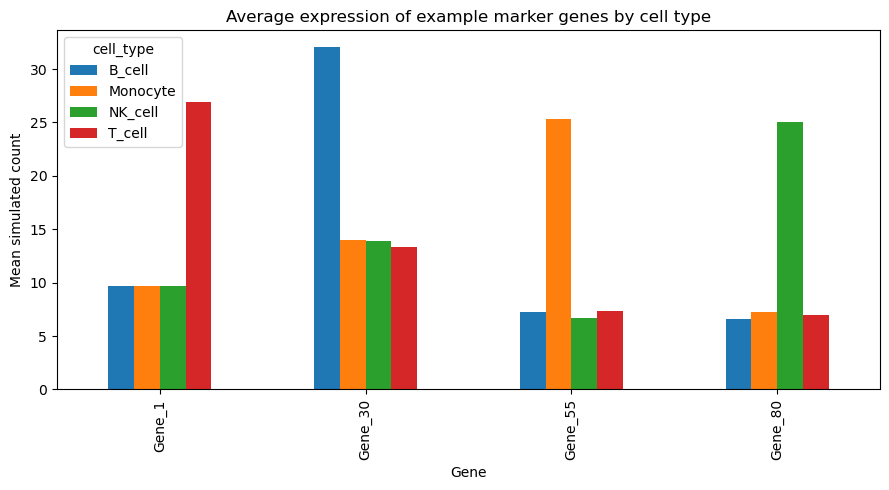

In [4]:
marker_means.T.plot(kind='bar', figsize=(9, 5))
plt.title('Average expression of example marker genes by cell type')
plt.xlabel('Gene')
plt.ylabel('Mean simulated count')
plt.tight_layout()
plt.show()


### Teaching note

This table and bar plot help students connect the mathematics back to biology:

- some genes behave like **marker genes**
- different cell populations have different expression signatures
- dimensionality reduction methods try to summarize patterns across **all genes at once**


## 5. Preprocessing for single-cell-style analysis

Real single-cell pipelines often involve steps such as:

- library size normalization
- log transformation
- variable gene selection
- scaling
- PCA

For teaching purposes, we will use a simplified version:

1. convert counts to a log-like scale using `log1p`
2. optionally keep the most variable genes
3. standardize features before PCA and t-SNE/UMAP comparisons

This is not a full production single-cell workflow, but it is very suitable for classroom explanation.


In [5]:
# Log-transform the count matrix
X_log = np.log1p(X)

# Compute per-gene variance on log scale
gene_variances = X_log.var(axis=0)

# Select top variable genes
n_top_genes = 100
top_gene_idx = np.argsort(gene_variances)[-n_top_genes:]
top_gene_names = [gene_names[i] for i in top_gene_idx]

X_hvg = X_log[:, top_gene_idx]

print("Shape after selecting top variable genes:", X_hvg.shape)
print("Example selected genes:", top_gene_names[:10])


Shape after selecting top variable genes: (600, 100)
Example selected genes: ['Gene_144', 'Gene_135', 'Gene_132', 'Gene_26', 'Gene_142', 'Gene_222', 'Gene_163', 'Gene_189', 'Gene_276', 'Gene_121']


In [6]:
# Standardize selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hvg)

print("Scaled matrix shape:", X_scaled.shape)


Scaled matrix shape: (600, 100)


## 6. A helper function for plotting embeddings

In [7]:
def plot_embedding(X_2d, labels, title='Embedding', figsize=(6, 5), alpha=0.8):
    label_order = pd.unique(labels)
    plt.figure(figsize=figsize)
    for lab in label_order:
        mask = labels == lab
        plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=18, alpha=alpha, label=lab)
    plt.title(title)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. PCA on single-cell-style data

In many real single-cell workflows, PCA is the first major dimensionality reduction step after preprocessing.

Why?

- it is fast
- it reduces thousands of genes to a smaller set of components
- it can suppress some noise
- it produces coordinates that can then be used for neighborhood graph construction or nonlinear embedding

We begin by projecting the cells into the first two principal components.


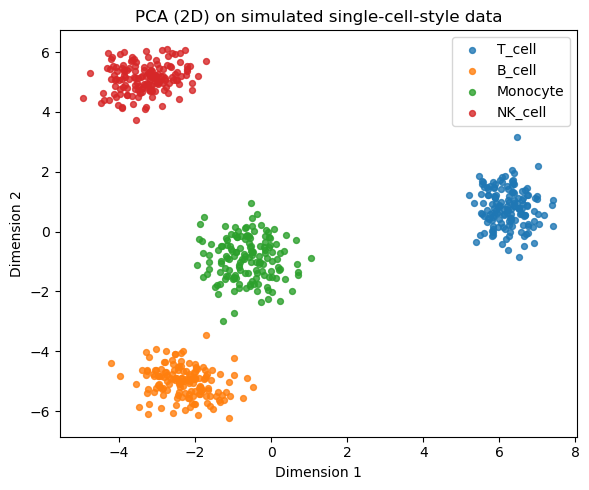

Explained variance ratio of PC1 and PC2: [0.14167477 0.13578417]
Total explained variance by first 2 PCs: 0.2774589387924967


In [8]:
pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(X_scaled)

plot_embedding(X_pca_2d, y, title='PCA (2D) on simulated single-cell-style data')

print("Explained variance ratio of PC1 and PC2:", pca_2.explained_variance_ratio_)
print("Total explained variance by first 2 PCs:", pca_2.explained_variance_ratio_.sum())


### Teaching discussion

Questions to ask students:

1. Do the cell types separate clearly in the first two PCs?
2. Does PCA capture the major biological differences?
3. Why might some populations still overlap even if they are biologically distinct?

Important point:

PCA is **linear**, so it cannot always reveal complex nonlinear structure in the data.


## 8. A broader PCA view: cumulative explained variance

One advantage of PCA is that it gives a direct variance-based summary.
This is very useful pedagogically and practically.


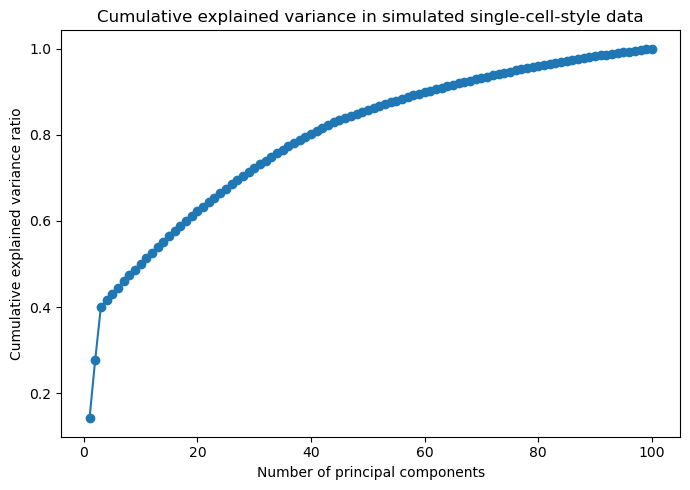

In [9]:
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance ratio')
plt.title('Cumulative explained variance in simulated single-cell-style data')
plt.tight_layout()
plt.show()


## 9. t-SNE on single-cell-style data

t-SNE is widely used in single-cell visualization because it often creates visually distinct groups of cells that reflect local neighborhood structure.

However, students must understand an important caution:

- t-SNE is primarily a **visualization method**
- distances between far-separated clusters are often **not reliable**
- the visual result depends on hyperparameters and random seed


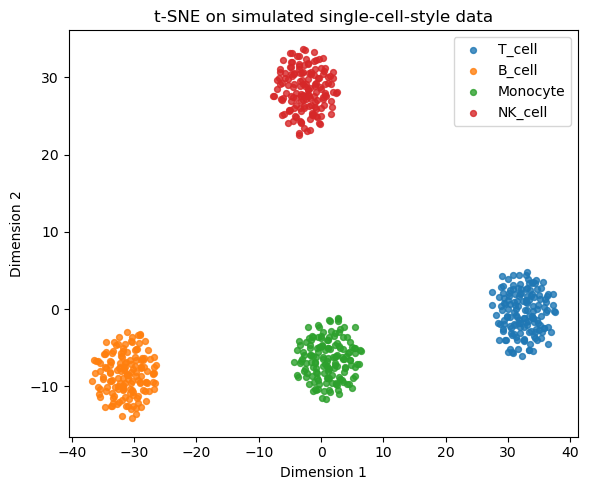

In [10]:
# In many workflows, t-SNE is run on PCA scores rather than all genes directly
pca_30 = PCA(n_components=30)
X_pca_30 = pca_30.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)
X_tsne_2d = tsne.fit_transform(X_pca_30)

plot_embedding(X_tsne_2d, y, title='t-SNE on simulated single-cell-style data')


### Teaching note

This is a good moment to explain why people often run:

- preprocessing
- PCA
- then t-SNE

instead of giving t-SNE the full gene matrix directly.

Reason:
PCA reduces noise and makes the nonlinear step more stable and computationally manageable.


## 10. UMAP on single-cell-style data

UMAP is now very common in single-cell analysis.

Why is it popular?

- it is often fast
- it often gives visually meaningful cell embeddings
- it preserves local neighborhood structure well
- it often provides a useful balance between local and broader structure

As with t-SNE, students should treat it as an exploratory embedding, not a perfect picture of biological truth.


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


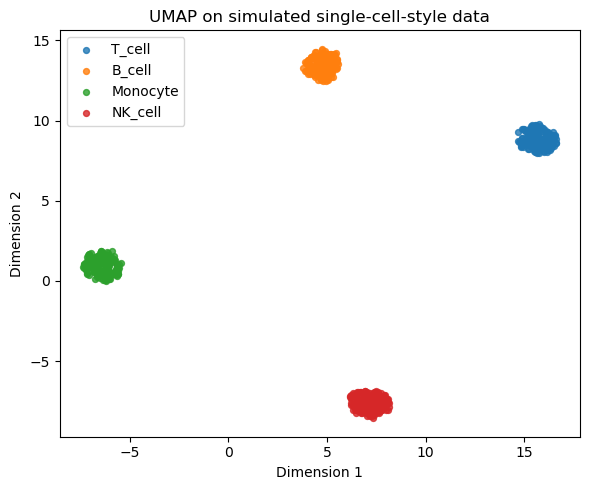

In [11]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
X_umap_2d = umap_reducer.fit_transform(X_pca_30)

plot_embedding(X_umap_2d, y, title='UMAP on simulated single-cell-style data')


## 11. Side-by-side biological interpretation

Now compare the three embeddings:

- **PCA**: Which cell types separate along broad linear axes?
- **t-SNE**: Which cell types form tight visual groups?
- **UMAP**: Which cell types remain distinct, and which appear closer together?

---
### Important caution for students

A cluster in a t-SNE or UMAP plot does **not automatically prove** a biologically discrete cell type.

Possible reasons for apparent separation include:

- true cell identity differences
- preprocessing choices
- batch effects
- stochastic variation
- parameter settings

This is a very important scientific interpretation lesson.


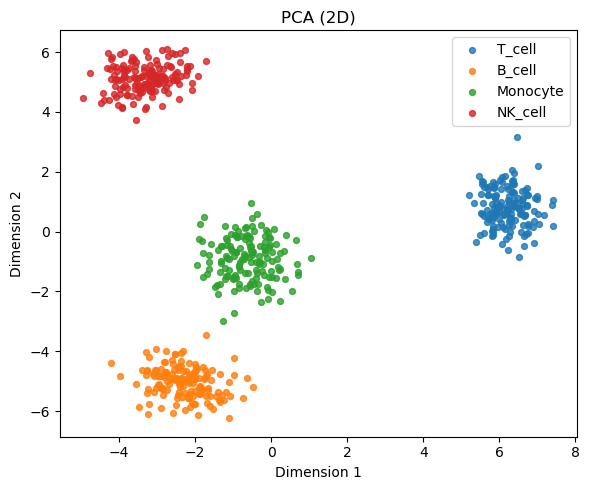

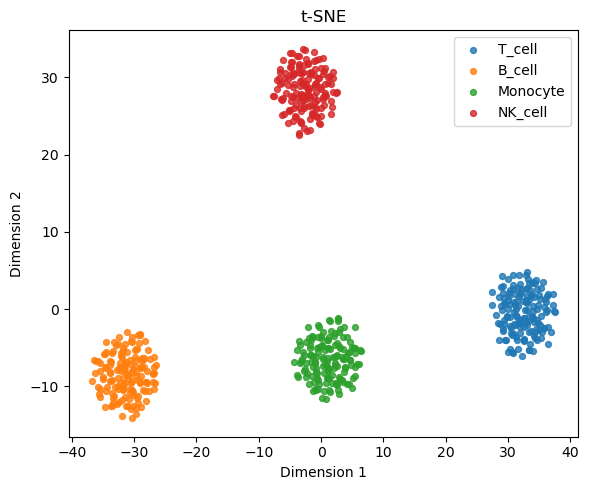

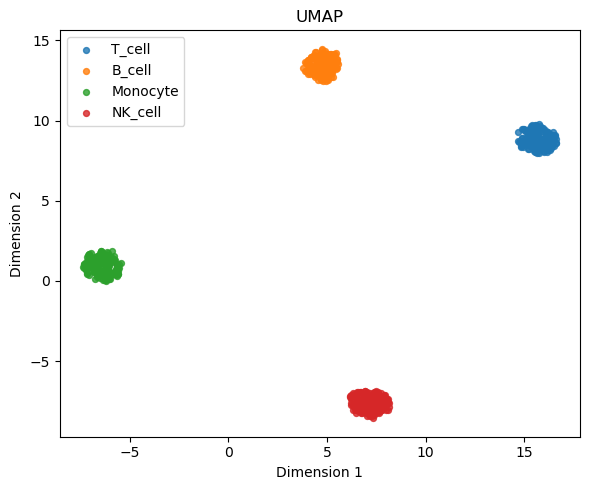

In [12]:
plot_embedding(X_pca_2d, y, title='PCA (2D)')
plot_embedding(X_tsne_2d, y, title='t-SNE')
plot_embedding(X_umap_2d, y, title='UMAP')


## 12. Compare how t-SNE changes with perplexity

A major lesson in single-cell visualization is that the embedding is not uniquely determined.
We will vary the t-SNE perplexity and observe the effect.


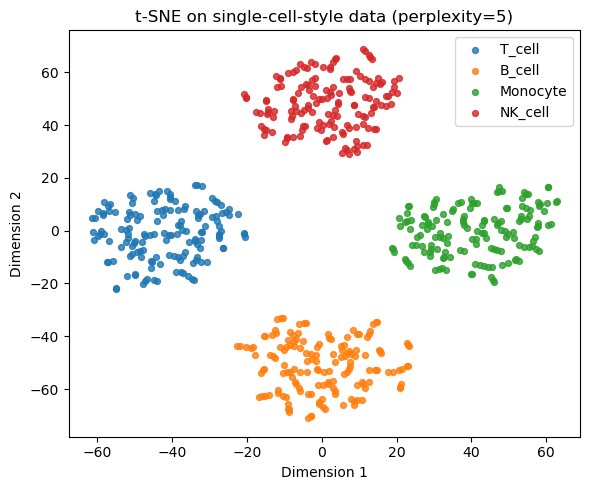

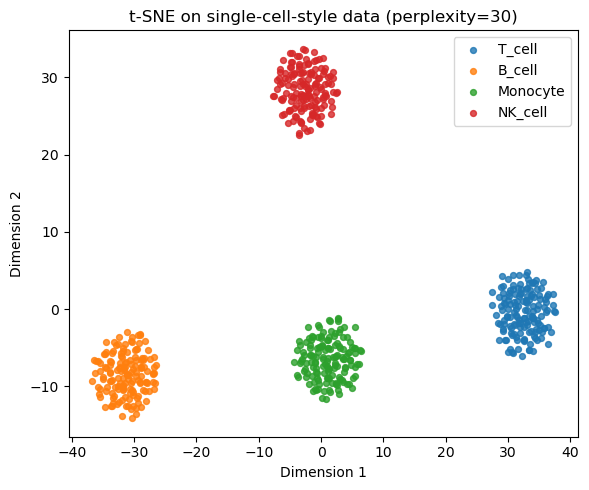

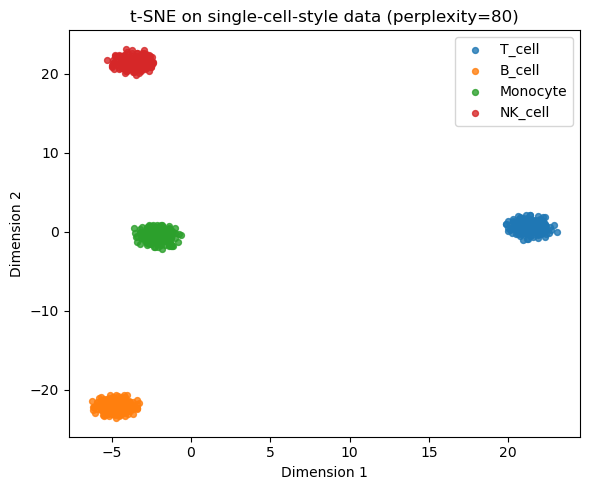

In [13]:
perplexities = [5, 30, 80]

for p in perplexities:
    X_tsne_var = TSNE(
        n_components=2,
        perplexity=p,
        random_state=42,
        init='pca',
        learning_rate='auto'
    ).fit_transform(X_pca_30)

    plot_embedding(X_tsne_var, y, title=f't-SNE on single-cell-style data (perplexity={p})')


### Teaching message

Students should notice:

- cluster shapes may change
- distances among groups may change
- broad layout may change substantially

Therefore, t-SNE is useful for **exploration**, but not for making strong claims about exact global geometry.


## 13. Compare how UMAP changes with `n_neighbors` and `min_dist`

These two hyperparameters are central for interpreting UMAP results.

- `n_neighbors` influences the scale of local structure used to build the embedding
- `min_dist` influences how tightly points are packed


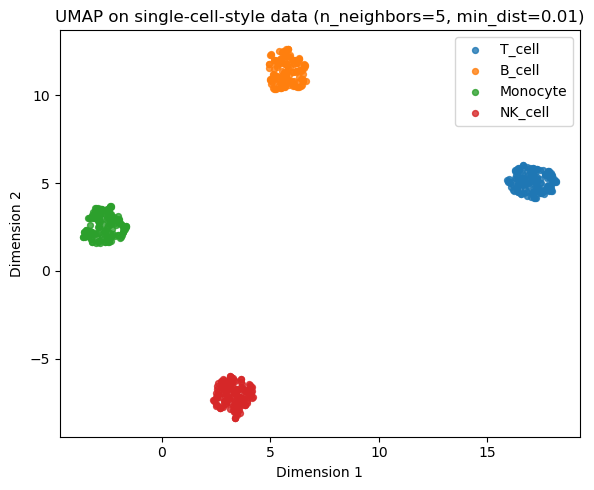

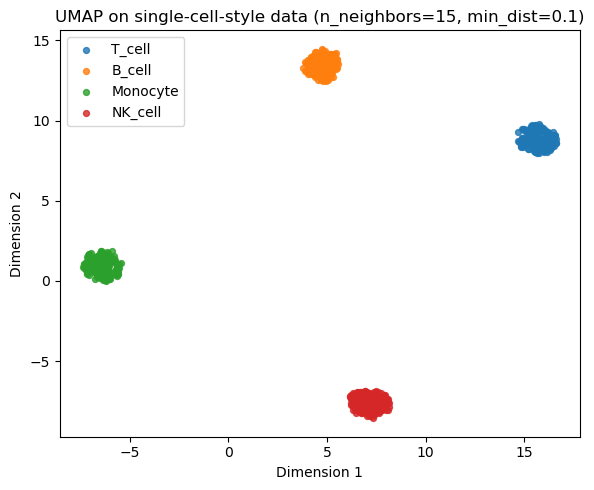

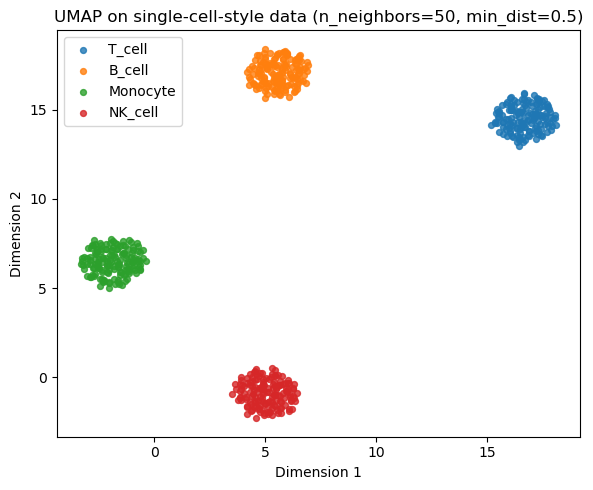

In [14]:
umap_settings = [
    {'n_neighbors': 5, 'min_dist': 0.01},
    {'n_neighbors': 15, 'min_dist': 0.1},
    {'n_neighbors': 50, 'min_dist': 0.5}
]

for setting in umap_settings:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=setting['n_neighbors'],
        min_dist=setting['min_dist'],
        random_state=42
    )
    X_umap_var = reducer.fit_transform(X_pca_30)
    plot_embedding(
        X_umap_var,
        y,
        title=f"UMAP on single-cell-style data (n_neighbors={setting['n_neighbors']}, min_dist={setting['min_dist']})"
    )


### Teaching message

This is a strong point of comparison with t-SNE:

- UMAP also depends on hyperparameters
- smaller `min_dist` often creates tighter cell clusters
- larger `n_neighbors` often makes broader structure more visible

Again, the embedding is a modeling choice, not an objective photograph of the biology.


## 14. Feature loadings for PCA: connecting math to genes

One strength of PCA in bioinformatics is that we can inspect which genes contribute strongly to each component.

This gives students a bridge between:

- abstract linear algebra
- biological interpretation


In [15]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=top_gene_names,
    columns=['PC1_loading', 'PC2_loading']
)

top_pc1 = loadings['PC1_loading'].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings['PC2_loading'].abs().sort_values(ascending=False).head(10)

print("Top genes contributing to PC1:")
display(loadings.loc[top_pc1.index].sort_values('PC1_loading', ascending=False))

print("Top genes contributing to PC2:")
display(loadings.loc[top_pc2.index].sort_values('PC2_loading', ascending=False))


Top genes contributing to PC1:


,PC1_loading,PC2_loading
Gene_10,0.229458,0.030705
Gene_23,0.218376,0.027451
Gene_22,0.215893,0.032170
Gene_18,0.213811,0.031459
Gene_4,0.213502,0.030102
Gene_20,0.212401,0.024206
Gene_11,0.211360,0.028603
Gene_19,0.210765,0.015525
Gene_2,0.210166,0.027644
Gene_15,0.209692,0.033379


Top genes contributing to PC2:


,PC1_loading,PC2_loading
Gene_76,-0.108215,0.192416
Gene_83,-0.098381,0.191156
Gene_87,-0.117431,0.188438
Gene_86,-0.114122,0.187292
Gene_80,-0.109068,0.187030
Gene_81,-0.102802,0.185640
Gene_94,-0.110231,0.185393
Gene_96,-0.102200,0.184885
Gene_99,-0.113675,0.182635
Gene_44,-0.071848,-0.186309


### Teaching point

PCA offers a more direct route to interpretation because we can ask:

> Which genes drive the major axes of variation?

That is much harder to do directly with t-SNE or UMAP.


## 15. Biological caveats to discuss in class

In real single-cell analysis, many additional issues matter:

- batch effects
- dropout and sparsity
- normalization method
- variable gene selection
- doublets
- cell cycle effects
- technical noise
- sequencing depth differences

This notebook simplifies many of those issues so students can focus on the **core geometry and interpretation** of PCA, t-SNE, and UMAP.


## 16. Summary table in a single-cell context

In [16]:
comparison_df = pd.DataFrame({
    'Method': ['PCA', 't-SNE', 'UMAP'],
    'Role in single-cell workflows': [
        'Early dimensionality reduction and preprocessing backbone',
        'Visualization of local neighborhoods',
        'Visualization and exploration of cell-state structure'
    ],
    'Main strength': [
        'Fast, interpretable, variance-based, gene loadings available',
        'Often produces visually distinct cell groups',
        'Often flexible and effective for neighborhood-preserving embeddings'
    ],
    'Main caution': [
        'May miss nonlinear cell-state geometry',
        'Global distances and cluster spacing can be misleading',
        'Still parameter-sensitive and not a literal map of biology'
    ]
})

comparison_df


,Method,Role in single-cell workflows,Main strength,Main caution
0,PCA,Early dimensionality reduction and preprocessi...,"Fast, interpretable, variance-based, gene load...",May miss nonlinear cell-state geometry
1,t-SNE,Visualization of local neighborhoods,Often produces visually distinct cell groups,Global distances and cluster spacing can be mi...
2,UMAP,Visualization and exploration of cell-state st...,Often flexible and effective for neighborhood-...,Still parameter-sensitive and not a literal ma...


## 17. Exercises for students

### Conceptual questions
1. Why is PCA often used before t-SNE or UMAP in single-cell workflows?
2. Why might two cell types overlap in PCA but separate in UMAP?
3. Why should we be cautious about interpreting the distance between two clusters in t-SNE?
4. Why are PCA loadings easier to connect to genes than t-SNE or UMAP coordinates?

### Coding exercises
1. Increase the number of marker genes per cell type and see what happens.
2. Increase the noise level and compare the three methods again.
3. Change the number of selected variable genes.
4. Run t-SNE and UMAP directly on the scaled matrix instead of PCA coordinates. Compare the results.
5. Add a fifth cell type with partially overlapping marker genes.

### Reflection question
When does a visually clean embedding help biological understanding, and when might it oversimplify the biology?


## 18. Reusable template for student projects

Students can adapt the template below to their own gene expression matrix.


In [ ]:
# Example template for your own single-cell-style dataset

# X_counts = your raw or normalized expression matrix (cells x genes)
# y_labels = optional known labels such as annotated cell types

# Step 1: log transform if appropriate
# X_log = np.log1p(X_counts)

# Step 2: choose variable genes if desired
# gene_variances = X_log.var(axis=0)
# top_idx = np.argsort(gene_variances)[-1000:]
# X_selected = X_log[:, top_idx]

# Step 3: scale
# X_scaled = StandardScaler().fit_transform(X_selected)

# Step 4: PCA
# X_pca = PCA(n_components=30).fit_transform(X_scaled)

# Step 5: t-SNE
# X_tsne = TSNE(
#     n_components=2,
#     perplexity=30,
#     random_state=42,
#     init='pca',
#     learning_rate='auto'
# ).fit_transform(X_pca)

# Step 6: UMAP
# X_umap = umap.UMAP(
#     n_components=2,
#     n_neighbors=15,
#     min_dist=0.1,
#     random_state=42
# ).fit_transform(X_pca)

# Step 7: plot
# plot_embedding(X_tsne, y_labels, title='t-SNE')
# plot_embedding(X_umap, y_labels, title='UMAP')


## 19. Final takeaway

For single-cell-style data:

- **PCA** is often the foundational first reduction step
- **t-SNE** is powerful for local visualization
- **UMAP** is also powerful and widely used for cell embedding
- all three methods are useful, but they answer different questions

The key scientific lesson is this:

> A low-dimensional plot is a helpful model of the data, not the data itself.
